# Data Scientist Associate Practical Exam Submission

This is my submission to the Data Scientist Associate certification exam

## Background
* EMO is a manufacturer of electric motorcycles
* EMO launched its first electric motorcycle in India in 2019
* The Product team has been asking website users to rate the motorcycles
* Ratings from owners help the product team to improve the quality of the motorcycles
* Ratings from non-owners help the product team add new features. They hope the new features will increase the number of new customers
* The product team wants to extend the survey. But, they want to be sure they can predict whether the ratings came from owners or non-owners.

## Tasks
These are the tasks required for passing the test
1. For every column in the data:
	1. State whether the values match the description given in the table below.
	2. State the number of missing values in the column
	3. Describe what you did to make values match the description if they did not match.
2. Create a visualization that shows how many reviews were from owners and how many were not owners. Use the visualization to:
	1. State which category of the variable owned has the most number of observations
	2. Explain whether the observations are balanced across categories of the variable owned
3. Describe the distribution of overall rating across the possible values. **Your answer must include a visualization that shows the distribution.**
4. Describe the relationship between ownership and overall rating. **Your answer must include a visualization to demonstrate the relationship.**
5. The business wants to predict whether a review came from an owner or not using the data provided. **State the type of machine learning problem that this is (regression/classification/clustering).**
6. Fit a baseline model to predict whether a review came from an owner or not using the data provided. **You must include your code.**
7. Fit a comparison model to predict whether a review came from an owner or not using the data provided. **You must include your code.**
8. Explain why you chose the two models used in parts 6 and 7.
9. Compare the performance of the two models used in parts 6 and 7, using any method suitable for the type of model. **You must include your code.**
10. Explain which model performs better and why.

## Data
The [dataset](electric_bike_ratings_2212.csv) contains  rating information about mopeds collected by the product team.
| Column Name     | Criteria                                                       |
|-----------------|----------------------------------------------------------------|
| owned           | **Nominal**. Whether the reviewer owns the moped (1) or not (0). **Missing values should be removed**. |
| make_model      | **Nominal**. The make and model of the bike, one of six possible values (Nielah-Eyden, Nielah-Keetra, Lunna-Keetra, Hoang-Keetra, Lunna-Eyden, Hoang-Eyden). **Replace missing values with “unknown”**. |
| review_month    | **Nominal**. The month the review was given in English short format (Jan, Feb, Mar, Apr etc.). **Replace missing values with “unknown”.** |
| web_browser     | **Nominal**. Web browser used by the user leaving the review, one of Chrome, IE, Firefox, Safari, Android, Opera. **Replace missing values with “unknown”.** |
| reviewer_age    | **Discrete**. Age of the user leaving the review. Integer values from 16. **Replace missing values with the average age.** |
| primary_use     | **Nominal**. The main reason the user reports that they use the bike for. One of Commuting or Leisure. **Replace missing values with “unknown”.** |
| value_for_money | **Discrete**. Rating given by the user on value for money of the bike. Rating from 1 to 10. **Replace missing values with 0.** |
| overall_rating  | **Continuous**. Total rating score after combining multiple rating scores. Continuous values from 0 to 25 are possible. **Replace missing values with the average rating.** |



## Task 1 
The dataset contains **1500 rows and 8 columns**  with missing values before cleaning. After validating all the columns, the columns and criteria are as follow:
* **Owned**: Same as description without missing values, 2 unique values
* **Make model:** Same as description without missing values
* **Review month:** Got the month from the string in the values. No missing values
* **Web browser**: 150 missing values, I replace missing values with 'unknown'
* **Reviewer age:** 105 missing values, originally set to the string `'-'`, I replaced missing values with the mean age. Converted into numerical type
* **Primary use:** Same as description without missing values
* **Value for money:** No missing values. 10 unique values. Converted into numerical type
* **Overall rating:** Same as description without missing values

In [1]:
#Importing Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Read csv file
df = pd.read_csv('electric_bike_ratings_2212.csv')

#Check info
display(df.info())
print('Na values: \n' + str(df.isna().sum()) +'\n')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   owned            1500 non-null   int64  
 1   make_model       1500 non-null   object 
 2   review_month     1500 non-null   object 
 3   web_browser      1350 non-null   object 
 4   reviewer_age     1500 non-null   object 
 5   primary_use      1500 non-null   object 
 6   value_for_money  1500 non-null   object 
 7   overall_rating   1500 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 93.9+ KB


None

Na values: 
owned                0
make_model           0
review_month         0
web_browser        150
reviewer_age         0
primary_use          0
value_for_money      0
overall_rating       0
dtype: int64



,owned,make_model,review_month,web_browser,reviewer_age,primary_use,value_for_money,overall_rating
0,1,Nielah-Eyden,Oct,Chrome,23,Commuting,5/10,18.62
1,0,Nielah-Keetra,Jun,NaN,24,Commuting,4/10,15.55
2,0,Lunna-Keetra,23-Oct,Chrome,28,Commuting,5/10,12.76
3,1,Hoang-Keetra,07-Nov,IE,41,Leisure,5/10,17.07
4,1,Lunna-Keetra,16-Sep,Chrome,33,Leisure,5/10,12.29


### Validate categorical values

From the data description, it is expected to have a specific number of unique values for each categorical column. The expected values are:

*These values consider that the only column with missing values is the web_browser one, as shown above*

* **owned** - 2 unique values (1 and 0)
* **make_model** - 6 unique values (The 6 possible Make-Model combinations)
* **review_month** - 12 unique values (The 12 months in a year)
* **web_browser** - 7 unique values (6 possible browsers + `null`)
* **primary_use** - 2 unique values (Commuting and Leisure)
* **value_for_money** - 10 unique values (from 1/10 to 10/10)

In [3]:
cat_cols = ['owned', 'make_model', 'review_month', 'web_browser','primary_use','value_for_money']

for col in cat_cols:
    print(f'Unique {col}: ' + str(len(pd.unique(df[col]))))

Unique owned: 2
Unique make_model: 6
Unique review_month: 332
Unique web_browser: 7
Unique primary_use: 2
Unique value_for_money: 10


### Cleaning Month data
As the output above has shown, the amount of unique values in the categorical columns does not correspond to the expected amount in a column. Therefore, it is necessary to understand and act in a solution for these discrepancies. Here is the plan:
1. Check some of the `df.review_month` column in the `df.head()` output, shown before;
2. Observe that some of the data in this column present Date-Mon format and some only Mon format;
3. Extract the last 3 characters from the input as it shows the month abreviation, as described in the data description table;
4. Check if it worked (Unique values = 12).


In [4]:
#Create new column with month abbreviation: review_month_abbr
df['review_month'] = df.review_month.str[-3:]
display(df.review_month.head())

#Check amount of unique values
print('Unique review_month: ' + str(len(pd.unique(df['review_month']))))

0    Oct
1    Jun
2    Oct
3    Nov
4    Sep
Name: review_month, dtype: object

Unique review_month: 12


### Cleaning web_browser missing data
For the `web_browser` column to match the data description, the `null` values should be replace with the entry 'unknown'

In [5]:
df['web_browser'] = df.web_browser.fillna('unknown')
pd.unique(df.web_browser)

array(['Chrome', 'unknown', 'IE', 'Firefox', 'Safari', 'Android', 'Opera'],
      dtype=object)

### Validate numerical values

From the data description, it is expected that the numerical data columns match specific conditions.

* **reviewer_age** - numerical values only, minimum value >= 16 or missing data
* **value_for_money** - minimum value >= 1, maximum value <= 10 or missing data
* **overall_rating** - minimum value >= 0, maximum value <= 25 or missing data

In [6]:
num_cols = ['reviewer_age','value_for_money','overall_rating']
for col in num_cols:
    print(str(df[col].describe()))

count     1500
unique      36
top          -
freq       105
Name: reviewer_age, dtype: object
count     1500
unique      10
top       5/10
freq       387
Name: value_for_money, dtype: object
count    1500.000000
mean       17.138907
std         2.445566
min        11.690000
25%        15.320000
50%        18.240000
75%        18.840000
max        22.760000
Name: overall_rating, dtype: float64


### Cleaning numerical data
The output shwon above shows that there are two major problems with the data in these colums:
1. The `reviewer_age` column is not in the correct data type, it currently an `object` dtype and it should be a `int`
     1. This happens because there are 105 entries that are `'-'`;
     2. These values are going to be set as NaN and dealt with as the data description ask for
2. The `value_for_money` column is currently shown in a n/10 format, which makes managing and manipulating the data harder

In [7]:
df.replace('-',np.nan,inplace=True)
df['reviewer_age'] = df.reviewer_age.astype('float')
df.replace(np.nan,df['reviewer_age'].mean(),inplace=True)
df['reviewer_age'] = df.reviewer_age.astype('int')
df.reviewer_age.describe()

count    1500.000000
mean       32.556000
std         9.876769
min        16.000000
25%        24.000000
50%        32.000000
75%        41.000000
max        50.000000
Name: reviewer_age, dtype: float64

### Value_for_money approach
As it is not possible to convert a string in the format 'n/10' directly to a float, this problem will demand an out of the box approach.
1. The algorithm will split the string into two parts (numerator and denominator)
2. This new variables will then be used to get the value of the division and multiply it by 10

In [8]:
df['value_for_money'] = df['value_for_money'].apply(lambda x: (int(x.split('/')[0]) / int(x.split('/')[1]))*10)

In [9]:
df.value_for_money.describe()

count    1500.000000
mean        4.977333
std         1.486257
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: value_for_money, dtype: float64

### Final check
Now, it is necessary to check if the columns are in the correct dtype and finish the cleaning phase. Is is necessary to have 1500 non-null entries.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   owned            1500 non-null   int64  
 1   make_model       1500 non-null   object 
 2   review_month     1500 non-null   object 
 3   web_browser      1500 non-null   object 
 4   reviewer_age     1500 non-null   int64  
 5   primary_use      1500 non-null   object 
 6   value_for_money  1500 non-null   float64
 7   overall_rating   1500 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 93.9+ KB


## Task 2
From **Graph 1 | The Count of Owned**, most reviews come from people that own a moped. There is not a balance between the categories of the owned variable

In [11]:
sns.set_context('notebook')
sns.set_style('whitegrid')
sns.set_palette('colorblind')

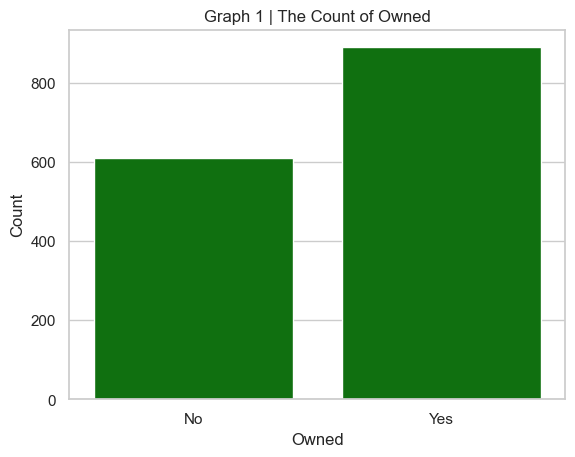

In [12]:
ax1 = sns.countplot(data=df, 
                   x='owned',
                   color='green')\
        .set(title="Graph 1 | The Count of Owned",
             xticklabels=['No','Yes'],
            xlabel='Owned',
            ylabel='Count')

## Task 3
From **Graph 2 | Overall Rating Distribution**, the overall rating values vary from 11 up to 22. There is a high count of values that fall inbetween **18.5 and 19.5**, this interval being the most common one, followed by the ranges from **14.5 up to 15.5** and **17.5 to 18.5**

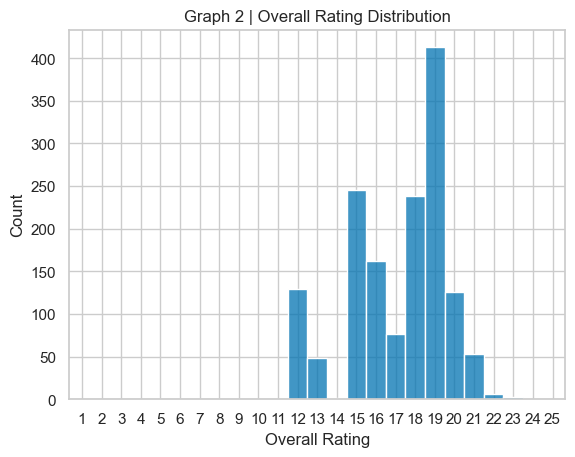

In [13]:
ax2 = sns.histplot(x='overall_rating',
                  data=df,
                  bins=np.arange(1.5,25.5,1)
                  )\
    .set(title='Graph 2 | Overall Rating Distribution',
        xlabel='Overall Rating',
        xticks=np.arange(1,26,1))

## Task 4
From **Graph 3 | Relationship Between Ownership and Overal Rating**, all the quartiles are set at a greater overall rating in the owners reviews when compared to the reviews of people that do not own a moped. 

A good measure of the data comparisson is the median (the line crossing in the middle of the box) and the height of the boxes (which shows the distance between the 1st and 3rd quartile. In this case, it is possible to observe that the median of reviews coming from people that own a moped is higher than the 3rd quartile of people that do not own a moped.

With what was stated above, it is possible to get two insights from the graph. People who own a moped tend to have aa greater overall rating of the product when compared to people that do not own a moped. Furthermore, the opinions in from people that own a moped differ less than the opinion of people who don't own one.

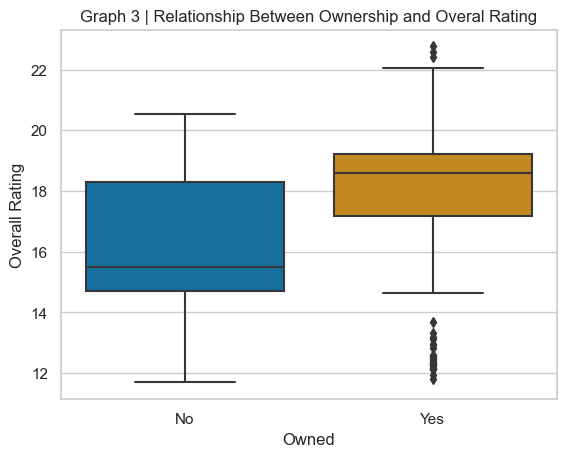

In [14]:
ax3 = sns.boxplot(data=df, 
                  x='owned',
                  y='overall_rating'
                 )\
        .set(title='Graph 3 | Relationship Between Ownership and Overal Rating',
            xlabel='Owned',
            xticklabels=['No', 'Yes'],
            ylabel='Overall Rating'
            )

## Task 5
 Predicting whether a review came from an owner or not is a **classification problem** in machine learning

### Changes to modeling
In order to be able to fit the data in a model, it is necessary to have the data as numerical data. The following changes are necessary:
* All categorical columns are converted to numeric variables;
* Split data into features and 

In [15]:
# Importing packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [16]:
features = df.drop('owned', axis=1)

In [17]:
#Convert to numeric and split data
X = pd.get_dummies(features, columns=['make_model', 'review_month', 'web_browser','primary_use'], drop_first=True)
y = df['owned']

In [18]:
#Split data into 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2710, stratify=y )

## Task 6
Baseline model - K Neighbors Classifier model

In [19]:
# Fitting KNeighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_predict = knn.predict(X_test)

## Task 7
Comparisson model - Random  Forrest Classifier model

In [20]:
# Fitting Random Forest
rand_for_class = RandomForestClassifier()
rand_for_class.fit(X_train, y_train)
rand_for_class_predict = rand_for_class.predict(X_test)

## Task 8
I am choosing **K-Neighbors Classifier** as a baseline model because it is simple to use, train and evaluate. The comparisson model chosen is the **Random Forest Classifier** because it is able to observe more complex relationships between the features, which could lead to a better performance

## Task 9
I am choosing **Accuracy Score** as my performance evaluator because it is a simple to understand variable, while still a good way to check the performance of a model

### Evaluating KNeighbors Model

In [21]:
knn_acc = accuracy_score(y_test, knn_predict)
print(f'KNN accuracy score: {knn_acc}')

KNN accuracy score: 0.7066666666666667


### Evaluating Random Forest Model

In [22]:
rand_for_class_acc = accuracy_score(y_test, rand_for_class_predict)
print(f'Random Forest accuracy score: {rand_for_class_acc}')

Random Forest accuracy score: 0.7266666666666667


## Task 10
A bigger accuracy score means a better perfomance. the accuracy score could be transformed into a percentage of right predictions made by the model.

This mean the **Random Forest Model** had a better performance when compared to the **K-Neighbors model** for predicting wheter or not a review comes from a owner of the products.